In [24]:
import pandas as pd

df = pd.read_csv("BerkeleyBusinesses.csv")
df.head()

,APN,RecordID,BusDesc,B1_PER_SUB_TYPE,DBA,NAICS,Tax_Code,Employee_Num,Bus_Own_Type,B1_BUSINESS_NAME,...,B1_ADDRESS2,B1_CITY,B1_STATE,B1_ZIP,B1_CONTACT_TYPE,B1_FULL_ADDRESS,B1_SITUS_CITY,B1_SITUS_STATE,B1_SITUS_ZIP,Business_Location
0,ZZZZZZZZZZZZZ,BL-023794,CONTRACTOR,Construction or Contractor,J&J PRO BUILDERS INC,236220 - Commercial and Institutional Building...,C,9,Corporation,J&J PRO BUILDERS INC,...,NaN,TRACY,CA,95304,Business Owner,0 VARIOUS,BERKELEY,CA,94704,NaN
1,ZZZZZZZZZZZZZ,BL-023954,SOAPS & CANDLES,Retail Trade,ONNEJ,459999 - All Other Miscellaneous Retailers,R,0,Sole Ownership,ONNEJ,...,NaN,RICHMOND,CA,94801,Business Owner,0 VARIOUS,BERKELEY,CA,94704,NaN
2,ZZZZZZZZZZZZZ,BL-023542,GENERAL CONTRACTOR,Construction or Contractor,JDS CONSTRUCTION ENTERPRISE INC,236118 - Residential Remodelers,C,6,Corporation,JDS CONSTRUCTION ENTERPRISE INC,...,NaN,SAN PABLO,CA,94806,Business Owner,0 VARIOUS,BERKELEY,CA,94704,NaN
3,ZZZZZZZZZZZZZ,BL-022440,IT,Professional SemiProfessional,ALSOTECH,541519 - Other Computer Related Services,P,0,Sole Ownership,ALSOTECH,...,NaN,OAKLAND,CA,94619,Business Owner,0 VARIOUS,BERKELEY,CA,94704,NaN
4,053 170105900,BL-054023,FLORAL HOME BUSINESS,Retail Trade,BLUMA- THE ARTFUL BOTANIC,453110 - Florists,R,1,Sole Ownership,BLUMA- THE ARTFUL BOTANIC,...,NaN,BERKELEY,CA,94705,Business Owner,2827 PALM Ct,BERKELEY,CA,94705,NaN


In [2]:
df.columns

Index(['APN', 'RecordID', 'BusDesc', 'B1_PER_SUB_TYPE', 'DBA', 'NAICS',
       'Tax_Code', 'Employee_Num', 'Bus_Own_Type', 'B1_BUSINESS_NAME',
       'B1_ADDRESS1', 'B1_ADDRESS2', 'B1_CITY', 'B1_STATE', 'B1_ZIP',
       'B1_CONTACT_TYPE', 'B1_FULL_ADDRESS', 'B1_SITUS_CITY', 'B1_SITUS_STATE',
       'B1_SITUS_ZIP', 'Business_Location'],
      dtype='str')

In [3]:
berkeley_df = df[df["B1_CITY"].str.contains("Berkeley", case=False, na=False)]

In [5]:
berkeley_address = df[df["B1_FULL_ADDRESS"].str.contains("Berkeley", case=False, na=False)]

In [9]:
berkeley_address["B1_FULL_ADDRESS"].head(10)

102    1533 BERKELEY WAY
156    1728 BERKELEY Way
225    1732 BERKELEY Way
364    1810 BERKELEY WAY
509    1743 BERKELEY WAY
714    1246 BERKELEY WAY
824    1739 BERKELEY WAY
907           0 Berkeley
948    1369 BERKELEY WAY
982    1239 BERKELEY WAY
Name: B1_FULL_ADDRESS, dtype: str

In [11]:
berkeley_df["full_address_clean"] = (
    berkeley_df["B1_FULL_ADDRESS"] + ", " +
    berkeley_df["B1_CITY"] + ", " +
    berkeley_df["B1_STATE"] + " " +
    berkeley_df["B1_ZIP"]
)

In [12]:
berkeley_df["full_address_clean"].head(10)

4              2827 PALM Ct, BERKELEY, CA 94705
5        2081 CENTER St, BERKELEY, CA 947041204
6            1799 FOURTH ST, BERKELEY, CA 94710
7         2601 CHANNING WAY, BERKELEY, CA 94709
10       2081 CENTER St, BERKELEY, CA 947041204
11           1730 CURTIS ST, BERKELEY, CA 94702
13      72 SAN MATEO Rd, BERKELEY, CA 947072016
15    1454 BANCROFT Way, BERKELEY, CA 94702 194
16      1008 UNIVERSITY AVE, BERKELEY, CA 94710
18         3201 COLLEGE AVE, BERKELEY, CA 94705
Name: full_address_clean, dtype: str

In [14]:
berkeley_df = berkeley_df.dropna(subset=["B1_FULL_ADDRESS", "B1_CITY", "B1_ZIP"])

In [25]:
berkeley_df["location"] = berkeley_df["full_address_clean"].apply(geocode)

NameError: name 'geocode' is not defined

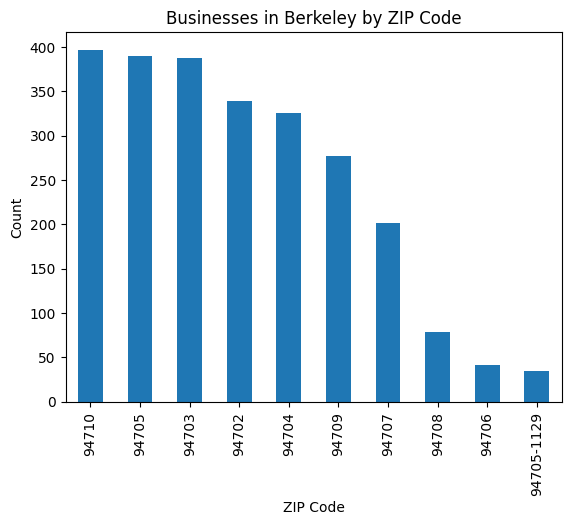

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("BerkeleyBusinesses.csv")

berkeley_df = df[df["B1_CITY"].str.contains("Berkeley", case=False, na=False)].copy()

berkeley_df["B1_ZIP"] = berkeley_df["B1_ZIP"].astype(str)

berkeley_df["B1_ZIP"].value_counts().head(10).plot(kind="bar")
plt.title("Businesses in Berkeley by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("Count")
plt.show()